# Autoencoder model

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.metrics import roc_auc_score

### Dataset and DataLoader

In [2]:
dataset = 'dataset_224x224'

class MVTecDataset(Dataset):
    def __init__(self, dataset_path, transform=None, mode="train"):
        super().__init__()
        self.transform = transform
        self.data = []
        
        categories = sorted([c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))])
        
        for category in categories:
            if mode == "train":
                good_path = os.path.join(dataset_path, category, "train", "good")
                for filename in os.listdir(good_path):
                    self.data.append((os.path.join(good_path, filename), 0))
            
            elif mode == "test":
                test_path = os.path.join(dataset_path, category, "test")
                for subfolder in os.listdir(test_path):
                    full_path = os.path.join(test_path, subfolder)
                    label = 0 if subfolder == "good" else 1
                    for filename in os.listdir(full_path):
                        self.data.append((os.path.join(full_path, filename), label))
        
        np.random.shuffle(self.data)
        print(f"[{mode}] Total images: {len(self.data)}")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        path, label = self.data[index]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = MVTecDataset(dataset, transform=transform, mode="train")
test_dataset = MVTecDataset(dataset, transform=transform, mode="test")

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

[train] Total images: 3629
[test] Total images: 1725
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


### Autoencoder model

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

### Training

In [4]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
loss_list = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for images, _ in train_dataloader:
        images = images.to(device)
        
        optimizer.zero_grad()
        reconstruction = model(images)
        loss = criterion(reconstruction, images)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_dataloader)
    loss_list.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "models/autoencoder_model.pth")

Epoch [1/20] | Loss: 0.0980
Epoch [2/20] | Loss: 0.0333
Epoch [3/20] | Loss: 0.0266
Epoch [4/20] | Loss: 0.0253
Epoch [5/20] | Loss: 0.0249
Epoch [6/20] | Loss: 0.0245
Epoch [7/20] | Loss: 0.0243
Epoch [8/20] | Loss: 0.0242
Epoch [9/20] | Loss: 0.0242
Epoch [10/20] | Loss: 0.0240
Epoch [11/20] | Loss: 0.0239
Epoch [12/20] | Loss: 0.0240
Epoch [13/20] | Loss: 0.0238
Epoch [14/20] | Loss: 0.0238
Epoch [15/20] | Loss: 0.0237
Epoch [16/20] | Loss: 0.0236
Epoch [17/20] | Loss: 0.0236
Epoch [18/20] | Loss: 0.0235
Epoch [19/20] | Loss: 0.0235
Epoch [20/20] | Loss: 0.0234


### Loss graph

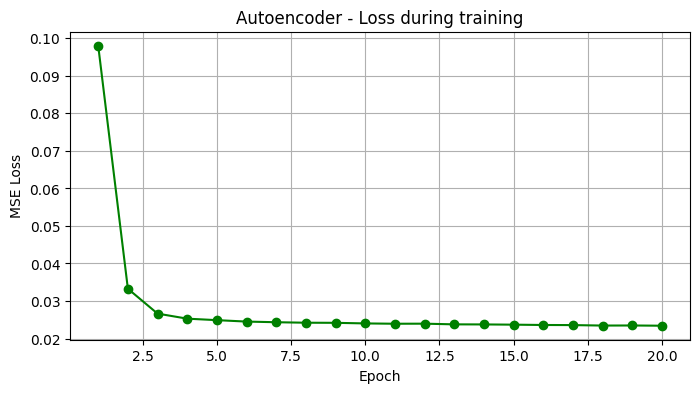

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), loss_list, marker='o', color='green')
plt.title("Autoencoder - Loss during training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### Evaluation

In [6]:
model.eval()
errors = []
all_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        reconstruction = model(images)
        error = ((images - reconstruction) ** 2).mean(dim=[1, 2, 3])
        errors.extend(error.cpu().numpy())
        all_labels.extend(labels.numpy())

errors = np.array(errors)
all_labels = np.array(all_labels)

thresholds = np.linspace(errors.min(), errors.max(), 100)
best_accuracy = 0
best_threshold = 0

for t in thresholds:
    pred = (errors > t).astype(int)
    if (pred == all_labels).mean() > best_accuracy:
        best_accuracy = (pred == all_labels).mean()
        best_threshold = t

predictions = (errors > best_threshold).astype(int)
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Autoencoder accuracy: {best_accuracy*100:.2f}%")
print(f"AUC-ROC: {roc_auc_score(all_labels, errors):.4f}")

Optimal threshold: 0.0050
Autoencoder accuracy: 72.87%
AUC-ROC: 0.5465


### Reconstruction visualization

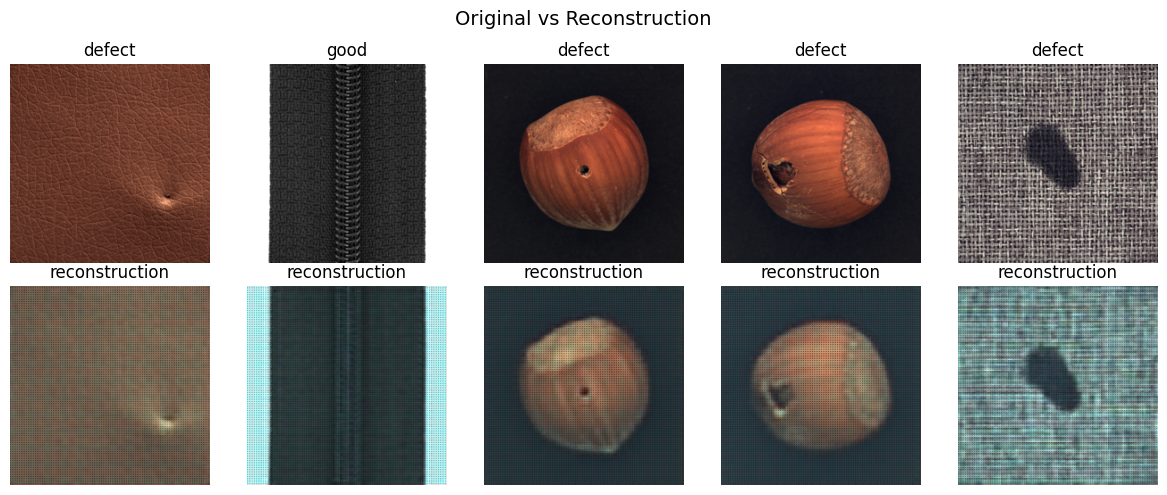

In [7]:
images, labels = next(iter(test_dataloader))
images = images.to(device)

model.eval()
with torch.no_grad():
    reconstruction = model(images)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Original vs Reconstruction", fontsize=14)

for i in range(5):
    image = images[i].cpu().permute(1, 2, 0).numpy()
    image = (image - image.min()) / (image.max() - image.min())
    axes[0, i].imshow(image)
    axes[0, i].set_title(f"{'good' if labels[i]==0 else 'defect'}")
    axes[0, i].axis("off")
    
    recon = reconstruction[i].cpu().permute(1, 2, 0).numpy()
    recon = (recon - recon.min()) / (recon.max() - recon.min())
    axes[1, i].imshow(recon)
    axes[1, i].set_title("reconstruction")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### Reconstruction error distribution

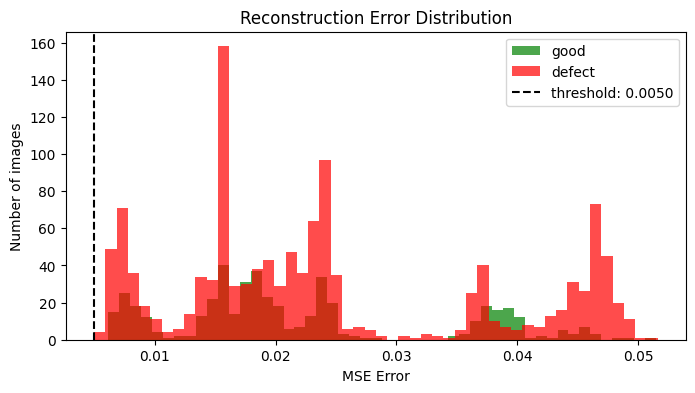

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(errors[all_labels == 0], bins=50, alpha=0.7, label='good', color='green')
plt.hist(errors[all_labels == 1], bins=50, alpha=0.7, label='defect', color='red')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'threshold: {best_threshold:.4f}')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE Error")
plt.ylabel("Number of images")
plt.legend()
plt.show()